# ThinkLab NLP Project
## Product Review Sentiment Classification

Hello! I'm **Shalitha**, and I'm excited to share my work on this Natural Language Processing project, focusing on product review sentiment classification. I've explored two distinct approaches to tackle this problem: a **Support Vector Machine (SVM)** for the traditional machine learning aspect, and a **BERT** model for a deep learning perspective. This notebook will walk through the implementation and evaluation of these models.

### Importing the Dataset


In [1]:
import pandas as pd

df = pd.read_csv('/content/Womens Clothing E-Commerce Reviews.csv')
display(df.head())

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


This code loads the `Womens Clothing E-Commerce Reviews.csv` dataset into a pandas DataFrame called `df`. Then, it displays the first 5 rows of the DataFrame to show a quick preview of the data.

In [2]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 23486
Number of columns: 11


This code prints the total number of rows and columns in the `df` DataFrame, giving an overview of its size.

In [3]:
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values)

Missing values per column:


,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


This code checks for missing values in each column of the `df` DataFrame and displays the count of missing values for each column. This helps identify columns that might need data cleaning.

In [4]:
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['Rating'].apply(get_sentiment)

This code defines a function `get_sentiment` that categorizes review ratings into 'Positive', 'Neutral', or 'Negative'. It then applies this function to the 'Rating' column to create a new 'sentiment' column in the `df` DataFrame.

In [5]:
display(df[['Review Text', 'sentiment']].head(10))

,Review Text,sentiment
0,Absolutely wonderful - silky and sexy and comf...,Positive
1,Love this dress! it's sooo pretty. i happene...,Positive
2,I had such high hopes for this dress and reall...,Neutral
3,"I love, love, love this jumpsuit. it's fun, fl...",Positive
4,This shirt is very flattering to all due to th...,Positive
5,"I love tracy reese dresses, but this one is no...",Negative
6,I aded this in my basket at hte last mintue to...,Positive
7,"I ordered this in carbon for store pick up, an...",Positive
8,I love this dress. i usually get an xs but it ...,Positive
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",Positive


This code displays the first 10 rows of the 'Review Text' and 'sentiment' columns from the `df` DataFrame, allowing a quick check of the assigned sentiments.

### Cleaning 'Review Text' Column

I will now clean the 'Review Text' column by performing the following steps:
1.  **Remove Missing Reviews**: Drop rows where 'Review Text' is null.
2.  **Convert to Lowercase**: Change all characters to lowercase.
3.  **Remove Punctuation**: Delete all punctuation marks.
4.  **Remove Special Characters**: Eliminate any non-alphanumeric characters.
5.  **Remove Extra Spaces**: Reduce multiple spaces to a single space and strip leading/trailing spaces.
6.  **Remove Duplicate Reviews**: Identify and remove duplicate entries based on the cleaned review text.

In [6]:
# 1. Remove Missing Reviews
original_rows = df.shape[0]
df_cleaned = df.dropna(subset=['Review Text']).copy()
print(f"Removed {original_rows - df_cleaned.shape[0]} rows with missing 'Review Text'.")

Removed 845 rows with missing 'Review Text'.


This code removes rows from the DataFrame where the 'Review Text' is missing. It creates a new DataFrame `df_cleaned` for this purpose and prints how many rows were removed.

In [7]:
import re

def clean_text(text):
    # 2. Capital letters lowercase
    text = text.lower()
    # 3. Punctuation remove (keep spaces, remove all other punctuation)
    text = re.sub(r'[^"\w\s"]', '', text)
    # 4. Special characters remove (non-alphanumeric except spaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # 5. Extra spaces remove
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_cleaned['cleaned_data'] = df_cleaned['Review Text'].apply(clean_text)

This code defines a `clean_text` function that processes text by converting it to lowercase, removing punctuation, special characters, and extra spaces. It then applies this cleaning function to the 'Review Text' column of `df_cleaned` to create a new 'cleaned_data' column.

In [8]:
# 6. Remove Duplicate Reviews
original_cleaned_rows = df_cleaned.shape[0]
df_cleaned.drop_duplicates(subset=['cleaned_data'], inplace=True)
print(f"Removed {original_cleaned_rows - df_cleaned.shape[0]} duplicate reviews based on 'cleaned_data'.")

Removed 8 duplicate reviews based on 'cleaned_data'.


This code identifies and removes duplicate reviews based on the 'cleaned_data' column in `df_cleaned`. It prints the number of duplicate rows that were removed.

### Saving the Cleaned Data

This step saves the processed DataFrame to a new CSV file, ensuring that all cleaning operations are preserved for future use.

In [9]:
df_cleaned.to_csv('Womens Clothing E-Commerce Reviews_cleaned.csv', index=False)
print("Cleaned DataFrame saved to 'Womens Clothing E-Commerce Reviews_cleaned.csv'")

Cleaned DataFrame saved to 'Womens Clothing E-Commerce Reviews_cleaned.csv'


In [10]:
# Display all columns with the first 10 rows of the cleaned DataFrame
display(df_cleaned.head(10))

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,sentiment,cleaned_data
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Positive,absolutely wonderful silky and sexy and comfor...
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Positive,love this dress its sooo pretty i happened to ...
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Neutral,i had such high hopes for this dress and reall...
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Positive,i love love love this jumpsuit its fun flirty ...
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Positive,this shirt is very flattering to all due to th...
5,5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses,Negative,i love tracy reese dresses but this one is not...
6,6,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits,Positive,i aded this in my basket at hte last mintue to...
7,7,858,39,"Shimmer, surprisingly goes with lots","I ordered this in carbon for store pick up, an...",4,1,4,General Petite,Tops,Knits,Positive,i ordered this in carbon for store pick up and...
8,8,1077,24,Flattering,I love this dress. i usually get an xs but it ...,5,1,0,General,Dresses,Dresses,Positive,i love this dress i usually get an xs but it r...
9,9,1077,34,Such a fun dress!,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5,1,0,General,Dresses,Dresses,Positive,im 55 and 125 lbs i ordered the s petite to ma...


This code displays the first 10 rows of the `df_cleaned` DataFrame, showing all columns, to give a comprehensive view of the data after cleaning.

### Chart 1: Sentiment Distribution Bar Chart

This chart visualizes the number of reviews classified as 'Positive', 'Neutral', and 'Negative'. It helps in understanding the overall sentiment distribution within the dataset.

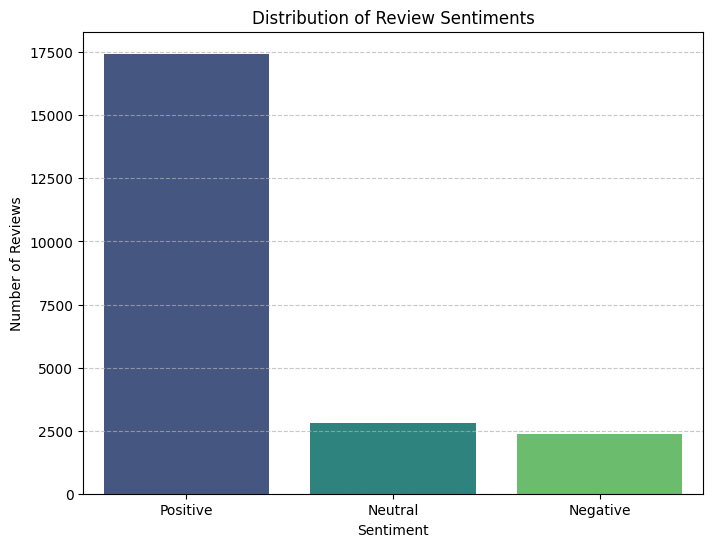

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'sentiment' column is available in df_cleaned
# This function was defined earlier (cell c3e5ee64)
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df_cleaned['sentiment'] = df_cleaned['Rating'].apply(get_sentiment)

# Calculate the counts for each sentiment category
sentiment_counts = df_cleaned['sentiment'].value_counts().reindex(['Positive', 'Neutral', 'Negative'])

# Create the bar plot
plt.figure(figsize=(8, 6))
# Fix for FutureWarning: Passing `palette` without assigning `hue`
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis', hue=sentiment_counts.index, legend=False)
plt.title('Distribution of Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This code generates a bar chart that shows the distribution of review sentiments (Positive, Neutral, Negative). It counts the occurrences of each sentiment and plots them, providing a visual summary of the sentiment breakdown.

### Chart 2: Word Count Distribution Chart

This chart shows the distribution of the number of words in each cleaned review. It helps to understand the length of the reviews, which can be useful for further text analysis or model training.

This code calculates the word count for each cleaned review and then creates a histogram to visualize the distribution of these word counts across all reviews.

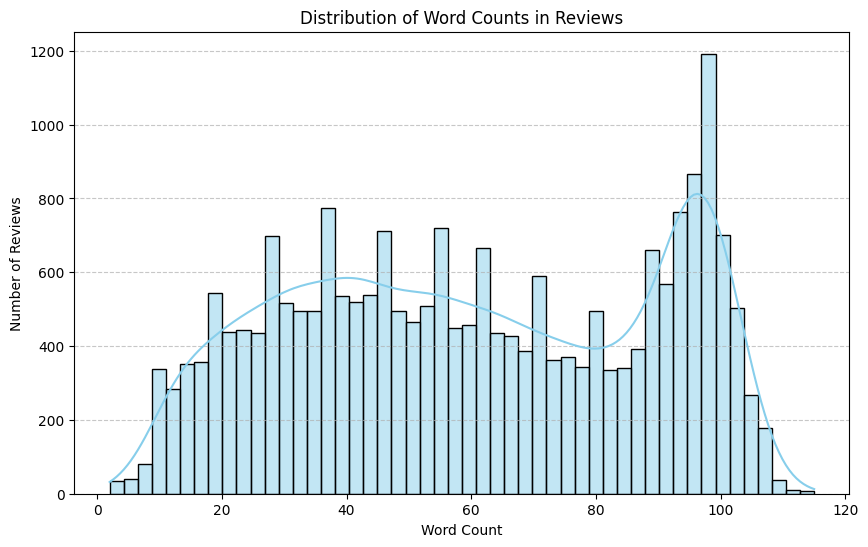

In [12]:
# Reset index to avoid 'ValueError: cannot reindex on an axis with duplicate labels'
df_cleaned = df_cleaned.reset_index(drop=True)

# Calculate word count for each cleaned review
df_cleaned['word_count'] = df_cleaned['cleaned_data'].apply(lambda x: len(str(x).split()))

# Create a histogram of word counts
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['word_count'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Word Counts in Reviews')
plt.xlabel('Word Count')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



---

✈

#Support Vector Machine (SVM) Model

SVM is a machine learning method that helps classify data. Imagine you have different groups of reviews (positive, neutral, negative). SVM finds the best possible line or boundary to separate these groups. The 'support vectors' are like the most important data points that help define this boundary. By doing this, SVM can effectively tell apart different sentiment categories, even with complex review data.

From now on, I will proceed with implementing this SVM model.

In [13]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_for_svm(text):
    # Tokenize and remove stopwords, then lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(cleaned_words)

# Apply preprocessing
df_cleaned['processed_text'] = df_cleaned['cleaned_data'].apply(preprocess_for_svm)

# Display the difference
display(df_cleaned[['cleaned_data', 'processed_text']].head(10))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,cleaned_data,processed_text
0,absolutely wonderful silky and sexy and comfor...,absolutely wonderful silky sexy comfortable
1,love this dress its sooo pretty i happened to ...,love dress sooo pretty happened find store im ...
2,i had such high hopes for this dress and reall...,high hope dress really wanted work initially o...
3,i love love love this jumpsuit its fun flirty ...,love love love jumpsuit fun flirty fabulous ev...
4,this shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...
5,i love tracy reese dresses but this one is not...,love tracy reese dress one petite 5 foot tall ...
6,i aded this in my basket at hte last mintue to...,aded basket hte last mintue see would look lik...
7,i ordered this in carbon for store pick up and...,ordered carbon store pick ton stuff always try...
8,i love this dress i usually get an xs but it r...,love dress usually get x run little snug bust ...
9,im 55 and 125 lbs i ordered the s petite to ma...,im 55 125 lb ordered petite make sure length w...


### Explanation of the Preprocessing Code:

1.  **NLTK Libraries**: I import `nltk` to use tools like `stopwords` (common words like 'the' or 'is' that are removed) and `WordNetLemmatizer` (which converts words back to their base form, e.g., 'running' becomes 'run').
2.  **`preprocess_for_svm` function**: This function takes the cleaned text, splits it into individual words, removes the 'stopwords', and applies lemmatization to each remaining word.
3.  **Applying to DataFrame**: I apply this function to our `cleaned_data` column to create a new `processed_text` column that is optimized for the machine learning model.

### TF-IDF Vectorization

Now I will convert the `processed_text` into a numerical format that the SVM can understand using TF-IDF (Term Frequency-Inverse Document Frequency).

In [14]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform the processed text
X = tfidf.fit_transform(df_cleaned['processed_text'])

# Target variable
y = df_cleaned['sentiment']

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (22633, 5000)


### Explanation of the TF-IDF Vectorization:

1.  **`TfidfVectorizer`**: Machine learning models like SVM cannot read raw text. This tool converts words into numbers based on how important they are in a specific review compared to the whole dataset.
2.  **`fit_transform`**: This 'learns' the vocabulary of your reviews and creates a mathematical matrix (`X`) representing every review as a series of numbers.
3.  **`y` variable**: This stores the target labels ('Positive', 'Neutral', 'Negative') that we want the model to predict.

### Step 1: Splitting the data
I split the data into two parts: a **Training set** to teach the model and a **Testing set** to check how good it is. We use 80% for training and 20% for testing.

In [15]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of testing samples: {X_test.shape[0]}")

Number of training samples: 18106
Number of testing samples: 4527


### Step 2: Training the SVM Model
I use a **Linear Support Vector Machine (SVM)**. This model is very good at categorizing text. It looks at the patterns in the words (numbers) to learn which ones belong to Positive, Neutral, or Negative sentiments.

In [16]:
from sklearn.svm import LinearSVC

# Create the model
svm_model = LinearSVC(random_state=42, max_iter=2000)

# Teach the model using our training data
svm_model.fit(X_train, y_train)

LinearSVC(max_iter=2000, random_state=42)

### Step 3: Checking the Results
Now I ask the model to predict the sentiment for the testing set. We use an **Accuracy Score** to see what percentage it got right, and a **Classification Report** to see more details.

In [17]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test data
y_pred = svm_model.predict(X_test)

# Show accuracy and the detailed report
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.820631764965761

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.59      0.47      0.52       474
     Neutral       0.42      0.27      0.33       565
    Positive       0.88      0.96      0.92      3488

    accuracy                           0.82      4527
   macro avg       0.63      0.57      0.59      4527
weighted avg       0.79      0.82      0.80      4527



### Step 4: Save the Model and Vectorizer
We save the `svm_model` and the `tfidf` vectorizer to files. This is important because to predict new text later, we must process it with the exact same TF-IDF vocabulary used during training.

In [18]:
import joblib

# Save the model to a file
joblib.dump(svm_model, 'svm_sentiment_model.joblib')

# Save the TF-IDF vectorizer to a file
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


### Chart 3: Confusion Matrix for SVM Model

A confusion matrix is a table that is often used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known. It allows us to visualize the performance of an algorithm. We will plot a confusion matrix to understand how well our SVM model distinguished between positive, neutral, and negative sentiments.

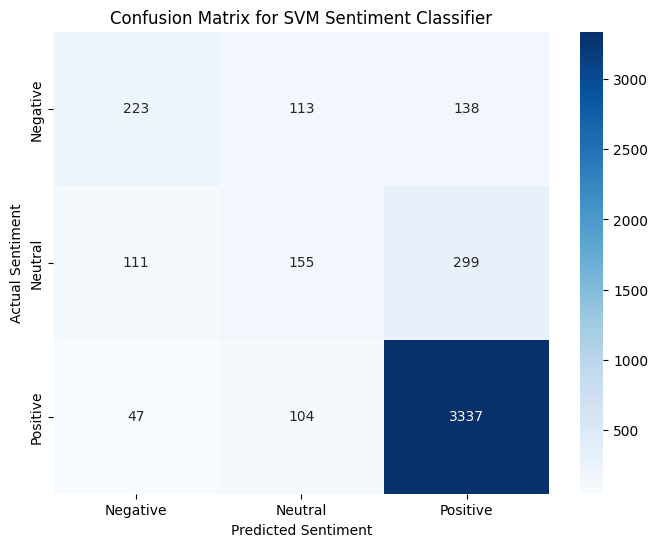

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get unique class labels for better visualization
class_labels = sorted(y.unique())

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for SVM Sentiment Classifier')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()



---



# BERT Deep Learning Model

BERT (Bidirectional Encoder Representations from Transformers) is a powerful deep learning model developed by Google. Unlike traditional models, BERT can understand the context of words in a sentence from both directions (left-to-right and right-to-left), allowing it to grasp the nuances of language more effectively. For sentiment classification, BERT can learn intricate patterns in review text to accurately categorize sentiments as 'Positive', 'Neutral', or 'Negative', often outperforming classical machine learning approaches.

Now, I will proceed with implementing this BERT model.

In [20]:
import os

# Set environment variable before importing tensorflow to ensure legacy Keras is used
os.environ['TF_USE_LEGACY_KERAS'] = 'True'

# Install transformers library and compatible tensorflow/tf_keras versions.
# IMPORTANT: After this cell executes, please RESTART the Colab runtime (Runtime -> Restart runtime)
# for the changes to take full effect before proceeding with the next steps.
!pip install transformers==4.38.2 tensorflow==2.21.0 tf_keras

print("Libraries installed. Please RESTART the Colab runtime (Runtime -> Restart runtime) now.")

Libraries installed. Please RESTART the Colab runtime (Runtime -> Restart runtime) now.


In [21]:
import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification, BertTokenizerFast

print("BERT model components imported successfully!")

BERT model components imported successfully!


### Loading Pre-trained BERT Model and Tokenizer

I'll load a pre-trained BERT base model and its corresponding tokenizer. The tokenizer converts text into a format BERT can understand, and the model provides the deep learning architecture.

In [22]:
import pandas as pd
from transformers import BertTokenizerFast

# Load pre-trained BERT tokenizer
model_name = 'bert-base-uncased'
tokenizer = BertTokenizerFast.from_pretrained(model_name)

# Ensure df_cleaned is loaded from the CSV at the start of this block
# Check if df_cleaned is not defined in globals, or if it's not a DataFrame
if 'df_cleaned' not in globals() or not isinstance(globals()['df_cleaned'], pd.DataFrame):
    try:
        df_cleaned = pd.read_csv('Womens Clothing E-Commerce Reviews_cleaned.csv')
        print("df_cleaned reloaded from 'Womens Clothing E-Commerce Reviews_cleaned.csv'.")
    except FileNotFoundError:
        print("Error: 'Womens Clothing E-Commerce Reviews_cleaned.csv' not found. Please ensure previous data cleaning cells were run and the file was saved.")
        raise # Stop execution as df_cleaned is critical
    except Exception as e:
        print(f"An unexpected error occurred while loading df_cleaned: {e}")
        raise

# If df_cleaned was successfully loaded, ensure 'sentiment' column is present
if 'sentiment' not in df_cleaned.columns:
    print("Warning: 'sentiment' column not found in df_cleaned. Attempting to re-derive from 'Rating'.")
    if 'Rating' in df_cleaned.columns:
        # Assuming the get_sentiment function from earlier cells is available or re-define it
        def get_sentiment(rating):
            if rating >= 4: return 'Positive'
            elif rating == 3: return 'Neutral'
            else: return 'Negative'
        df_cleaned['sentiment'] = df_cleaned['Rating'].apply(get_sentiment)
    else:
        raise ValueError("Cannot derive 'sentiment' as 'Rating' column is also missing in df_cleaned.")

# For sequence classification, we need to map our sentiment labels to integers
sentiment_map = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df_cleaned['sentiment_label'] = df_cleaned['sentiment'].map(sentiment_map)

# Verify the mapping
display(df_cleaned[['sentiment', 'sentiment_label']].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

,sentiment,sentiment_label
0,Positive,2
1,Positive,2
2,Neutral,1
3,Positive,2
4,Positive,2


### BERT Preprocessing Methods

Unlike traditional machine learning models (like SVM with TF-IDF), BERT uses its own specialized preprocessing. This means we *do not* perform traditional steps like stopword removal or lemmatization on the text before feeding it to BERT. Here's what BERT's preprocessing involves:

1.  **BERT Tokenizer**: BERT comes with its own tokenizer (e.g., `BertTokenizerFast`). This tokenizer is designed to convert raw text into a format that the BERT model can understand.
    *   **Subword Tokenization**: It breaks down words into subword units (e.g., 'unbelievable' might become 'un', '##believe', '##able'). This helps BERT handle out-of-vocabulary words and common prefixes/suffixes effectively.
    *   **Special Tokens**: The tokenizer automatically adds special tokens required by BERT, such as `[CLS]` at the beginning of the sequence (for classification tasks) and `[SEP]` at the end of each sentence.

2.  **Padding & Truncation**: All input sequences to BERT must have the same length. The tokenizer handles this:
    *   **Padding**: Shorter sequences are padded with `[PAD]` tokens until they reach a specified maximum length (`max_length`).
    *   **Truncation**: Longer sequences are cut short (truncated) to fit within the `max_length`.

3.  **Attention Masks**: Along with input IDs (numerical representations of tokens), the tokenizer generates attention masks. These masks tell BERT which tokens are actual words (`1`) and which are padding tokens (`0`), so the model doesn't pay attention to the padding.

By handling these steps internally, BERT's tokenizer prepares the data efficiently and in a way that maximizes the model's understanding of context and semantics.

### Tokenizing the Data

Here, the 'cleaned_data' column will be tokenized. This process converts text into numerical input IDs, attention masks, and token type IDs, which are necessary inputs for the BERT model.

In [23]:
max_length = 128 # Define maximum sequence length

# Tokenize the 'cleaned_data' column, returning numpy arrays first
encodings_np = tokenizer(list(df_cleaned['cleaned_data'].values), truncation=True, padding=True, max_length=max_length, return_tensors='np')

# Convert numpy arrays to TensorFlow tensors
encodings = {
    'input_ids': tf.constant(encodings_np['input_ids']),
    'attention_mask': tf.constant(encodings_np['attention_mask'])
}

# Prepare labels
labels = tf.constant(df_cleaned['sentiment_label'].values)

print(f"Shape of input_ids: {encodings['input_ids'].shape}")
print(f"Shape of attention_mask: {encodings['attention_mask'].shape}")
print(f"Shape of labels: {labels.shape}")

Shape of input_ids: (22633, 127)
Shape of attention_mask: (22633, 127)
Shape of labels: (22633,)


### Splitting the Data for BERT

Just like with the SVM model, the data needs to be split into training and testing sets. This ensures the model is evaluated on unseen data to assess its generalization capabilities.

In [24]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np

# Split data into training and testing sets
X_train_input_ids, X_test_input_ids, \
X_train_attention_mask, X_test_attention_mask, \
y_train_bert, y_test_bert = train_test_split(
    encodings['input_ids'].numpy(), # Convert to NumPy array
    encodings['attention_mask'].numpy(), # Convert to NumPy array
    labels.numpy(), # Convert to NumPy array
    test_size=0.2,
    random_state=42,
    stratify=labels.numpy() # This is already a NumPy array due to the conversion above
)

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(
    ({
        'input_ids': X_train_input_ids,
        'attention_mask': X_train_attention_mask
    },
    y_train_bert)
).batch(16)

test_dataset = tf.data.Dataset.from_tensor_slices(
    ({
        'input_ids': X_test_input_ids,
        'attention_mask': X_test_attention_mask
    },
    y_test_bert)
).batch(16)

print(f"Number of training samples for BERT: {len(X_train_input_ids)}")
print(f"Number of testing samples for BERT: {len(X_test_input_ids)}")

Number of training samples for BERT: 18106
Number of testing samples for BERT: 4527


### Defining the BERT Model

Now, I'll initialize the `TFBertForSequenceClassification` model from the pre-trained `bert-base-uncased` checkpoint. This model is designed for classification tasks and will be fine-tuned on our sentiment dataset. I'm setting the number of labels to 3 for 'Positive', 'Neutral', and 'Negative' sentiments.

In [25]:
# Load the pre-trained BERT model for sequence classification
# The 'num_labels' argument corresponds to the number of sentiment categories (Positive, Neutral, Negative)
bert_model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Configure the optimizer and loss function for training
# Using tf.keras.optimizers.legacy.Adam to resolve AttributeError related to _distribute_strategy
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=5e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')

# Compile the model
bert_model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

print("BERT model loaded and compiled successfully!")
bert_model.summary()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model loaded and compiled successfully!
Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_37 (Dropout)        multiple                  0 (unused)
                                                                 
 classifier (Dense)          multiple                  2307      
                                                                 
Total params: 109484547 (417.65 MB)
Trainable params: 109484547 (417.65 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Training the BERT Model

With the model defined and compiled, I'll now train it using our training dataset. BERT models are often fine-tuned over a few epochs, as they've already learned extensive language representations during pre-training.

In [26]:
# Train the model
history = bert_model.fit(
    train_dataset,
    epochs=3, # Typically 2-4 epochs are sufficient for fine-tuning BERT
    batch_size=16,
    validation_data=test_dataset
)

print("BERT model training complete!")

Epoch 1/3
1132/1132 [==============================] - 601s 511ms/step - loss: 0.4191 - accuracy: 0.8223 - val_loss: 0.3791 - val_accuracy: 0.8301
Epoch 2/3
1132/1132 [==============================] - 581s 513ms/step - loss: 0.3162 - accuracy: 0.8613 - val_loss: 0.3811 - val_accuracy: 0.8341
Epoch 3/3
1132/1132 [==============================] - 580s 512ms/step - loss: 0.2527 - accuracy: 0.8933 - val_loss: 0.4386 - val_accuracy: 0.8182
BERT model training complete!


### Evaluating the BERT Model

After training, it's crucial to evaluate the model's performance on the unseen test set to understand how well it generalizes. I will use a classification report to show precision, recall, and F1-score for each sentiment class, along with overall accuracy.

In [30]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test dataset
predictions = bert_model.predict(test_dataset)
logits = predictions.logits
y_pred_bert = np.argmax(logits, axis=1)

# Get true labels from the test_dataset (assuming it's structured as (features, labels))
y_true_bert = []
for _, labels_batch in test_dataset:
    y_true_bert.extend(labels_batch.numpy())

y_true_bert = np.array(y_true_bert)

# Print accuracy and classification report
print("BERT Model Accuracy:", accuracy_score(y_true_bert, y_pred_bert))
print("\nBERT Classification Report:")
print(classification_report(y_true_bert, y_pred_bert, target_names=['Negative', 'Neutral', 'Positive']))

283/283 [==============================] - 49s 173ms/step
BERT Model Accuracy: 0.8182018997128341

BERT Classification Report:
              precision    recall  f1-score   support

    Negative       0.56      0.64      0.60       474
     Neutral       0.38      0.53      0.44       565
    Positive       0.97      0.89      0.93      3488

    accuracy                           0.82      4527
   macro avg       0.64      0.69      0.66      4527
weighted avg       0.85      0.82      0.83      4527



### Chart: Confusion Matrix for BERT Model

To further visualize the BERT model's performance, I will create a confusion matrix. This matrix will help us understand which sentiment categories the model is accurately predicting and where it might be making errors.

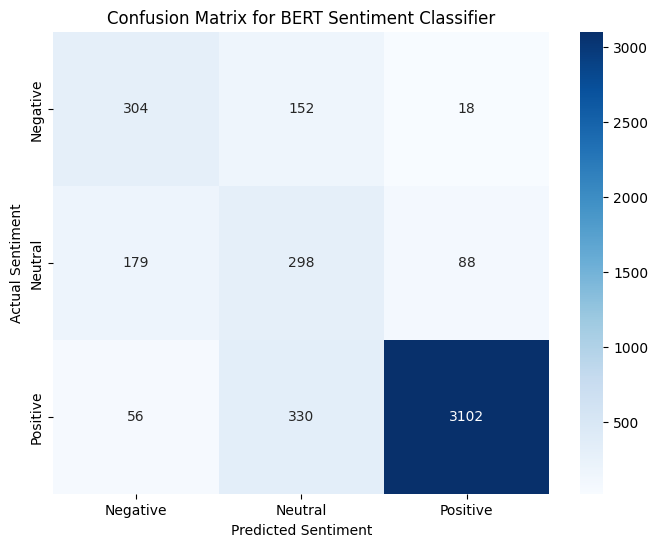

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

# Get class labels for visualization (matching sentiment_map)
class_labels_bert = ['Negative', 'Neutral', 'Positive']

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_bert, yticklabels=class_labels_bert)
plt.title('Confusion Matrix for BERT Sentiment Classifier')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

### Saving the BERT Model

Finally, I will save the trained BERT model. This allows us to reuse the model without needing to retrain it, which is especially useful for large models like BERT.

In [29]:
# Save the trained BERT model
bert_model.save_pretrained('./bert_sentiment_model')

print("BERT model saved successfully to './bert_sentiment_model'!")

BERT model saved successfully to './bert_sentiment_model'!
